In [1]:
import numpy as np

In [2]:
from configs import Configs
configs = Configs()
num_ics = 10
mesh = np.load("./data/train_valid/mesh_grid_coords.npy")
times = np.load("./data/train_valid/times.npy")
dt = times[1] - times[0]
num_times = times.shape[0]
solutions = np.load("./data/train_valid/solutions_grid_initials.npy", allow_pickle=True)
# solutions.shape --> [num_ics, num_times, 2, nx, ny]
Xs = np.zeros(
    ((num_times-1)*num_ics, 5, mesh.shape[0], mesh.shape[1])
)  # 5: phi, c, x, y, dt
Ys = np.zeros(
    ((num_times-1)*num_ics, 2, mesh.shape[0], mesh.shape[1])
)

for i in range(num_ics):
    Xs[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, :-1, 0, :, :]  # phi
    Xs[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, :-1, 1, :, :]  # c
    # mesh_x_repeated = np.repeat(mesh[:, :, 0][np.newaxis, :, :], num_times-1, axis=0)
    # Xs[i*(num_times-1):(i+1)*(num_times-1), 2, :, :] = mesh_x_repeated / configs.Lc  # x
    # mesh_y_repeated = np.repeat(mesh[:, :, 1][np.newaxis, :, :], num_times-1, axis=0)
    # Xs[i*(num_times-1):(i+1)*(num_times-1), 3, :, :] = mesh_y_repeated / configs.Lc # y
    Xs[i*(num_times-1):(i+1)*(num_times-1), 4, :, :] = dt / configs.Tc  # dt normalized by Tc)

    Ys[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, 1:, 0, :, :]  # phi at next time step
    Ys[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, 1:, 1, :, :]  # c
meshes_transposed = np.transpose(mesh, (2, 0, 1))  # (2, nx, ny)
meshes_repeated = np.repeat(meshes_transposed[np.newaxis, :, :, :], Xs.shape[0], axis=0)
Xs[:, 2, :, :] = meshes_repeated[:, 0, :, :] / configs.Lc  # x
Xs[:, 3, :, :] = meshes_repeated[:, 1, :, :] / configs.Lc # y

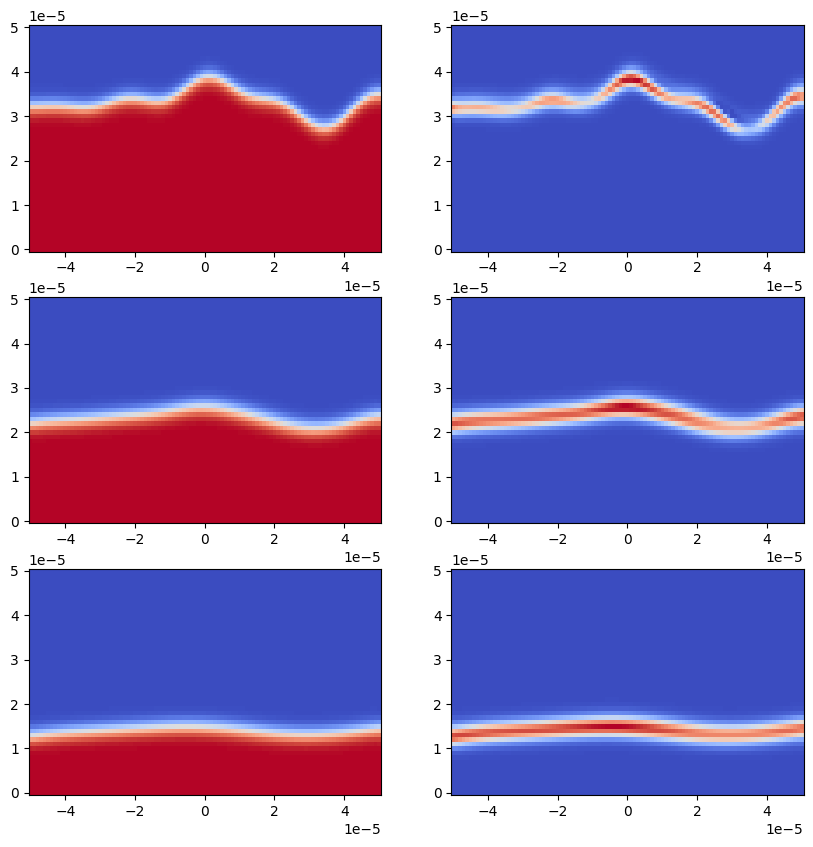

In [6]:
import matplotlib.pyplot as plt
ts = [0, 40, 99]
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for idx, t in enumerate(ts):
    t += 700
    x = Xs[t, 0, :, :]
    y = Ys[t, 0, :, :]
    meshx = Xs[t, 2, :, :] * configs.Lc
    meshy = Xs[t, 3, :, :] * configs.Lc
    ax = axes[idx, 0]
    im = ax.pcolormesh(meshx, meshy, x, cmap="coolwarm")

    ax = axes[idx, 1]
    diff = np.abs(y - x)
    im = ax.pcolormesh(meshx, meshy, diff, cmap="coolwarm")


In [4]:
np.savez(
    "./data/train_valid/dataset_2d_complete.npz",
    meshes=mesh/configs.Lc,
    times=times/configs.Tc,
    Xs=Xs,
    Ys=Ys,
)

In [5]:
times

array([    0.,   200.,   400.,   600.,   800.,  1000.,  1200.,  1400.,
        1600.,  1800.,  2000.,  2200.,  2400.,  2600.,  2800.,  3000.,
        3200.,  3400.,  3600.,  3800.,  4000.,  4200.,  4400.,  4600.,
        4800.,  5000.,  5200.,  5400.,  5600.,  5800.,  6000.,  6200.,
        6400.,  6600.,  6800.,  7000.,  7200.,  7400.,  7600.,  7800.,
        8000.,  8200.,  8400.,  8600.,  8800.,  9000.,  9200.,  9400.,
        9600.,  9800., 10000., 10200., 10400., 10600., 10800., 11000.,
       11200., 11400., 11600., 11800., 12000., 12200., 12400., 12600.,
       12800., 13000., 13200., 13400., 13600., 13800., 14000., 14200.,
       14400., 14600., 14800., 15000., 15200., 15400., 15600., 15800.,
       16000., 16200., 16400., 16600., 16800., 17000., 17200., 17400.,
       17600., 17800., 18000., 18200., 18400., 18600., 18800., 19000.,
       19200., 19400., 19600., 19800., 20000.])